# London air quality analysis

* Author: Andrew Sivanesan
* Date: 1st Feb 2026

## Executive summary

TBC

## Background

TBC

## Sources

* London Atmospheric Emissions Inventory 2022 (grid emissions summary). London Datastore (link [here](https://data.london.gov.uk/dataset/london-atmospheric-emissions-inventory-laei-2022-2lg5g/))
* May 2025 Local Authority District (LAD) boundaries (filtered for Kingston Upon Thames). Open Geography Portal - Office for National Statistics. (link [here](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-districts-may-2025-boundaries-uk-bfc-v2/explore?filters=eyJMQUQyNU5NIjpbIktpbmdzdG9uIHVwb24gVGhhbWVzIl0sIlNoYXBlX19BcmVhIjpbMjg4OTY3OS41Mjg0MzQ3NTM0LDI2MTU4NjY5Nzc0Ljk1MjYzN10sIlNoYXBlX19MZW5ndGgiOls5NDA0LjcxODk3MzQxNTg5Myw1MjM3NTA3LjM1ODU0MDQ2OF19&location=55.340000%2C-3.316939%2C5))
* Transport for London (TfL)'s air quality page (link [here](https://tfl.gov.uk/corporate/about-tfl/air-quality)))

In [1]:
import pandas as pd
from pyproj import CRS, Transformer
import seaborn as sns
import matplotlib.pyplot as plt
import folium
#from folium.plugins import HeatMap

## Data preparation

In [2]:
# Initialise a transformer that converts eastings and northings from the British National Grid coordinate reference system (CRS) to latitudes and longitudes in the WGS 1984 ellipsoid CRS
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326")

In [3]:
# define the name of the files to be read into this notebook
fname = "EmissionsByGridID_2022to2030.csv"
fname_boundary = "KingstonUponThamesBoundary.geojson"

In [29]:
# define filter condition
cond = (df["Year"] == 2022) & (df["Borough"] == "Kingston") & (df["Sector"] == "Road Transport")

# read in the file
df = pd.read_csv(fname)
# filter the data
df = df[cond].copy()

# create latitude and longitude columns
# This cell takes around 30 seconds to run
df["Latitude"] = df.apply(lambda x: transformer.transform(x["easting"], x["northing"])[0], axis=1)
df["Longitude"] = df.apply(lambda x: transformer.transform(x["easting"], x["northing"])[1], axis=1)

## Exploratory data analysis (all Kingston road transport emissions for 2022)

* Looking at the mean, median, upper quartile and maximum values: **carbon dioxide (co2)** is by far the largest of all the pollutants (in terms of tonnes per annum)
* There are multiple pollutants for which we have no data (e.g. bap, cd, c4h6 etc.)
* **All the pollutants are strongly positively correlated with each other**. Therefore we can reasonably focus the analysis on CO2 as a proxy for emissions across all pollutants. Any reduction in CO2 emissions will reduce emissions of all other pollutants.

FixMe(20260209)

* Focus the analysis on **road transport CO2 emissions**
* Identify **top 3 vehicle types** ("Source" column) by **median CO2 emissions** (use groupBy().agg() logic)
* Consider whether it's worth converting CO2 emissions into a normalised CO2 emissions score (between 0 and 1) for each vehicle type. This may aid comparison across vehicle types (e.g. if there are large differences in the order of magnitude of annual CO2 emissions across vehicle types)

In [38]:
pollutant_cols = ['bap', 'cd', 'c4h6', 'c6h6', 'ch4', 'co', 'co2', 'hc', 'hcl', 'hg', 'n2o', 'nh3', 'nmvoc', 'nox', 'pb', 'pcb', 'pm10', 'pm2.5', 'so2']

df[pollutant_cols].describe()

,bap,cd,c4h6,c6h6,ch4,co,co2,hc,hcl,hg,n2o,nh3,nmvoc,nox,pb,pcb,pm10,pm2.5,so2
count,0.0,0.0,0.0,0.0,885.000000,0.0,885.000000,0.0,0.0,0.0,885.000000,0.0,0.0,885.000000,0.0,0.0,885.000000,885.000000,0.0
mean,NaN,NaN,NaN,NaN,0.007166,NaN,193.111507,NaN,NaN,NaN,0.006342,NaN,NaN,0.351772,NaN,NaN,0.063597,0.030650,NaN
std,NaN,NaN,NaN,NaN,0.017247,NaN,475.144294,NaN,NaN,NaN,0.014769,NaN,NaN,0.881882,NaN,NaN,0.154698,0.074069,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.000157,NaN,NaN,0.001194,0.000595,NaN
50%,NaN,NaN,NaN,NaN,0.000298,NaN,23.514260,NaN,NaN,NaN,0.000733,NaN,NaN,0.028583,NaN,NaN,0.007006,0.003601,NaN
75%,NaN,NaN,NaN,NaN,0.001925,NaN,144.500248,NaN,NaN,NaN,0.005167,NaN,NaN,0.212111,NaN,NaN,0.040372,0.019270,NaN
max,NaN,NaN,NaN,NaN,0.130145,NaN,4707.255276,NaN,NaN,NaN,0.134449,NaN,NaN,7.940952,NaN,NaN,1.411963,0.666482,NaN


<Axes: >

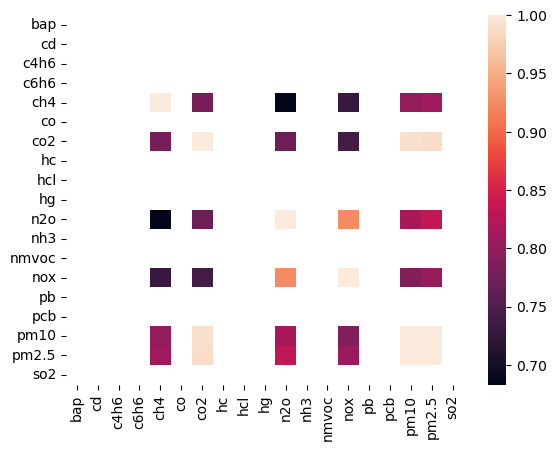

In [39]:
# Calculate the correlation matrix for the pollutants
corr = df[pollutant_cols].corr()

# plot the heatmap
sns.heatmap(corr)

## Exploratory data analysis (petrol cars)

* There are **59 rows** of Kingston petrol cars data.
* All columns are fully populated i.e. there are **no missing values.**
* The pm2.5 column is **right-skewed**: with multiple outliers beyond the upper quartile

In [24]:
# define the filter conditions
cond_kingston_petrol_cars = (df["Year"] == 2022) & (df["Borough"] == "Kingston") & (df["Source"] == "Car - Petrol")

# define the columns to select
#cols = ["LAEI 1km2 ID", "Latitude", "Longitude", "pm2.5"]

# apply filters and select columns
petrol_cars = df[cond_kingston_petrol_cars]#[cols]

In [26]:
petrol_cars.describe()

,LAEI 1km2 ID,Latitude,Longitude,pm2.5
count,59.000000,59.000000,59.000000,59.000000
mean,12236.118644,51.387458,-0.287401,0.174073
std,593.963951,0.030903,0.025799,0.168288
min,11252.000000,51.322682,-0.329473,0.000000
25%,11767.500000,51.366893,-0.311663,0.046236
50%,12114.000000,51.393323,-0.285099,0.133251
75%,12627.500000,51.411832,-0.268542,0.234304
max,13484.000000,51.438688,-0.239967,0.666482


In [7]:
petrol_cars.isnull().sum()

LAEI 1km2 ID    0
Latitude        0
Longitude       0
pm2.5           0
dtype: int64

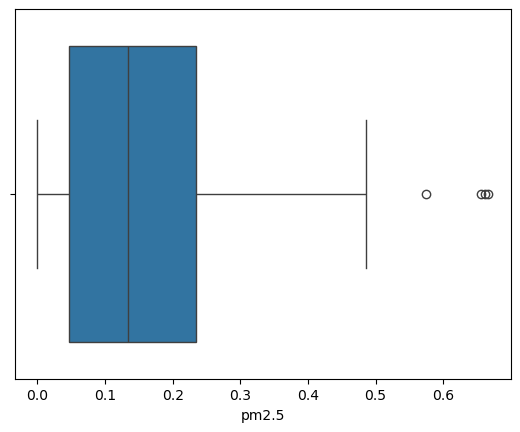

In [8]:
sns.boxplot(x=petrol_cars["pm2.5"])
plt.show()

In [27]:
# Apply Tukey's fence to filter for outlier values

LQ = petrol_cars["pm2.5"].quantile(0.25)
UQ = petrol_cars["pm2.5"].quantile(0.75)
IQR = UQ - LQ
tukey_fence_upper = UQ + (1.5 * IQR)
cond_tukey_fence_upper = petrol_cars["pm2.5"] > tukey_fence_upper

outliers = petrol_cars[cond_tukey_fence_upper].reset_index()
outliers

,index,LAEI 1km2 ID,Latitude,Longitude,pm2.5
0,416947,12113.0,51.393537,-0.255023,0.661589
1,416968,12454.0,51.376196,-0.298789,0.656297
2,417429,11766.0,51.412147,-0.297456,0.573877
3,417483,12455.0,51.375986,-0.284428,0.666482


## Visualise the emissions data

FixMe(20260208)

* Consider using Shapefiles to plot a polygon for each LAEI grid square to create a more visually appealing heatmap of pm2.5 emissions. Will need to use geopandas to convert the data into the GeoJSON format required by folium.

In [32]:
kingston_coords = [51.4123, -0.3007]
m1 = folium.Map(location=kingston_coords, zoom_start=12)

for i in range(len(outliers)):
    folium.Marker(
        location=[outliers["Latitude"][i], outliers["Longitude"][i]],
        tooltip=str(round(outliers["pm2.5"][i], 2)) + " of pm2.5 tonnes per annum"
    ).add_to(m1)

folium.GeoJson(fname_boundary).add_to(m1)

#HeatMap(outliers[["Latitude", "Longitude", "pm2.5"]]).add_to(m1)
m1